# PEARL — Exploratory Data Analysis

**Phase 1 deliverable for the Final Year defense.**

This notebook explores the raw PCOS ultrasound dataset before any preprocessing or modelling. It is the first artefact the panel will see, so the figures are sized for slides and the narrative is self-contained.

## What this notebook answers

1. How many images do we have, and how balanced are the classes?
2. What are the image dimensions, aspect ratios, and file sizes?
3. What does the pixel-intensity distribution look like per class?
4. Are there corrupt, blank, or duplicate images that would silently break training?
5. What does the 80/10/10 split look like before we lock it in?

## Inputs

Raw JPEG images under `data/`:

```
data/
├── infected/      ← PCOS-positive (label = 1)
└── noninfected/   ← PCOS-negative (label = 0)
```

All outputs (figures + summary tables) are written to `notebooks/eda_figures/` and `notebooks/eda_artifacts/` so they can be lifted directly into the defense slides.

## 0. Setup

Imports only — no model imports, no CUDA. The notebook should run on a laptop CPU in under a minute.

In [1]:
import hashlib
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

warnings.filterwarnings("ignore")

# ---- Paths ----
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = Path("./eda_figures")
ART_DIR = Path("./eda_artifacts")
FIG_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

# ---- Slide-ready matplotlib defaults ----
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

CLASS_MAP = {"noninfected": 0, "infected": 1}
CLASS_NAMES = {0: "Non-infected", 1: "Infected (PCOS)"}
CLASS_COLORS = {0: "#3a86ff", 1: "#e63946"}

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir    : {DATA_DIR}")
print(f"Figures →   : {FIG_DIR.resolve()}")
print(f"Artifacts → : {ART_DIR.resolve()}")

Project root: /home/farhan/my-projects/pearl
Data dir    : /home/farhan/my-projects/pearl/data
Figures →   : /home/farhan/my-projects/pearl/notebooks/eda_figures
Artifacts → : /home/farhan/my-projects/pearl/notebooks/eda_artifacts


## 1. Data inventory

Walk the directory structure, count images per class, and build a master DataFrame we can reuse for every later analysis.

In [2]:
def inventory_data(data_dir: Path) -> pd.DataFrame:
    """Walk the class subfolders and produce a row per image."""
    rows = []
    for class_name, label in CLASS_MAP.items():
        class_dir = data_dir / class_name
        if not class_dir.is_dir():
            print(f"  ! missing folder: {class_dir}")
            continue
        for fname in sorted(os.listdir(class_dir)):
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tiff")):
                rows.append({
                    "path": str(class_dir / fname),
                    "filename": fname,
                    "class_name": class_name,
                    "label": label,
                })
    return pd.DataFrame(rows)


df = inventory_data(DATA_DIR)
print(f"Total images: {len(df)}")
print(df["class_name"].value_counts().to_string())
df.head()

Total images: 11784
class_name
infected       6784
noninfected    5000


,path,filename,class_name,label
0,/home/farhan/my-projects/pearl/data/noninfecte...,Image_001.jpg,noninfected,0
1,/home/farhan/my-projects/pearl/data/noninfecte...,Image_002.jpg,noninfected,0
2,/home/farhan/my-projects/pearl/data/noninfecte...,Image_003.jpg,noninfected,0
3,/home/farhan/my-projects/pearl/data/noninfecte...,Image_004.jpg,noninfected,0
4,/home/farhan/my-projects/pearl/data/noninfecte...,Image_005.jpg,noninfected,0


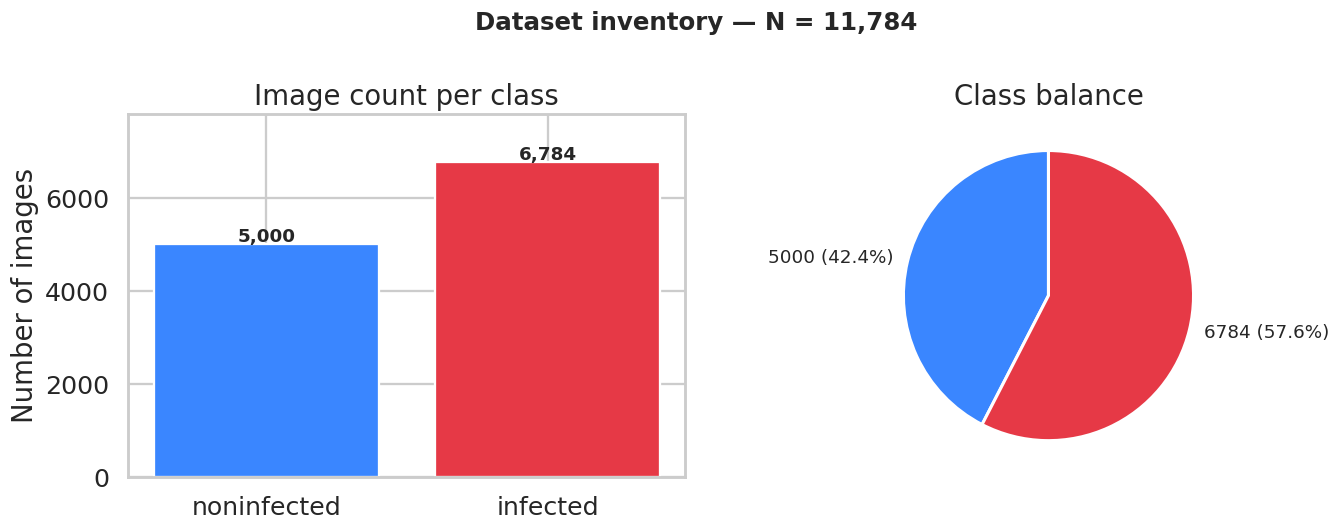


Class ratio (infected : noninfected) = 0.576 : 0.424
Imbalance ratio = 1.36x


In [3]:
counts = df["class_name"].value_counts().reindex(["noninfected", "infected"])
total = counts.sum()
ratios = counts / total

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bars = ax1.bar(counts.index, counts.values,
               color=[CLASS_COLORS[0], CLASS_COLORS[1]])
for b, v in zip(bars, counts.values):
    ax1.text(b.get_x() + b.get_width() / 2, v + 50, f"{v:,}",
             ha="center", fontsize=12, fontweight="bold")
ax1.set_title("Image count per class")
ax1.set_ylabel("Number of images")
ax1.set_ylim(0, counts.max() * 1.15)

ax2.pie(counts.values,
        labels=[f"{n} ({r:.1%})" for n, r in zip(counts.values, ratios)],
        colors=[CLASS_COLORS[0], CLASS_COLORS[1]],
        startangle=90, autopct=None,
        wedgeprops=dict(edgecolor="white", linewidth=2),
        textprops=dict(fontsize=12))
ax2.set_title("Class balance")

fig.suptitle(f"Dataset inventory — N = {total:,}", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_class_balance.png")
plt.show()

ratio_infected = ratios["infected"]
ratio_noninf = ratios["noninfected"]
print(f"\nClass ratio (infected : noninfected) = {ratio_infected:.3f} : {ratio_noninf:.3f}")
print(f"Imbalance ratio = {ratios.max() / ratios.min():.2f}x")

## 2. Image properties

For every image we read width, height, mode, and file size. This catches the common surprises: a few 4K outlier images, a couple of grayscale images masquerading as RGB, corrupted files.

In [4]:
def read_image_props(path: str) -> dict:
    """Cheap metadata-only read with PIL (does not decode pixels)."""
    try:
        with Image.open(path) as im:
            im.verify()  # catches truncated JPEGs
        size = os.path.getsize(path)
        with Image.open(path) as im:
            w, h = im.size
            mode = im.mode
        return {
            "width": w, "height": h,
            "mode": mode, "filesize_kb": size / 1024,
            "corrupt": False,
        }
    except Exception as e:
        return {
            "width": np.nan, "height": np.nan,
            "mode": None, "filesize_kb": np.nan,
            "corrupt": True, "error": str(e),
        }


props = df["path"].apply(read_image_props).apply(pd.Series)
df = pd.concat([df, props], axis=1)
df["aspect_ratio"] = df["width"] / df["height"]
df["megapixels"] = (df["width"] * df["height"]) / 1e6

print(f"Corrupt images: {df['corrupt'].sum()}")
print(f"Modes seen    : {df['mode'].value_counts().to_dict()}")
print(f"Resolutions   : {df.groupby(['width','height']).size().to_dict()}")
df.head()

Corrupt images: 0
Modes seen    : {'RGB': 11784}
Resolutions   : {(112, 112): 40, (116, 108): 52, (140, 129): 56, (149, 133): 56, (150, 150): 104, (160, 160): 44, (160, 315): 183, (171, 171): 48, (189, 257): 1, (197, 235): 1, (207, 254): 1, (210, 235): 1, (211, 274): 1, (213, 222): 1, (214, 217): 1, (214, 223): 1, (216, 233): 60, (216, 242): 1, (216, 243): 1, (216, 245): 1, (219, 246): 1, (219, 252): 1, (220, 208): 2, (220, 215): 1, (221, 241): 2, (221, 246): 1, (222, 268): 1, (223, 211): 1, (223, 228): 1, (223, 229): 2, (223, 239): 1, (223, 252): 2, (223, 265): 1, (224, 227): 1, (224, 228): 1, (224, 257): 1, (225, 225): 528, (225, 238): 1, (225, 242): 1, (225, 245): 1, (225, 246): 2, (226, 228): 1, (226, 232): 1, (226, 258): 1, (227, 216): 1, (227, 226): 2, (227, 228): 1, (227, 241): 2, (227, 242): 1, (227, 247): 1, (227, 254): 2, (227, 259): 1, (227, 300): 2, (228, 205): 1, (228, 210): 1, (228, 228): 1, (228, 237): 2, (228, 248): 1, (228, 254): 1, (228, 259): 1, (228, 293): 1, (228, 

,path,filename,class_name,label,width,height,mode,filesize_kb,corrupt,aspect_ratio,megapixels
0,/home/farhan/my-projects/pearl/data/noninfecte...,Image_001.jpg,noninfected,0,850,578,RGB,56.311523,False,1.470588,0.491300
1,/home/farhan/my-projects/pearl/data/noninfecte...,Image_002.jpg,noninfected,0,850,578,RGB,56.311523,False,1.470588,0.491300
2,/home/farhan/my-projects/pearl/data/noninfecte...,Image_003.jpg,noninfected,0,984,848,RGB,74.999023,False,1.160377,0.834432
3,/home/farhan/my-projects/pearl/data/noninfecte...,Image_004.jpg,noninfected,0,984,848,RGB,74.999023,False,1.160377,0.834432
4,/home/farhan/my-projects/pearl/data/noninfecte...,Image_005.jpg,noninfected,0,315,160,RGB,9.415039,False,1.968750,0.050400


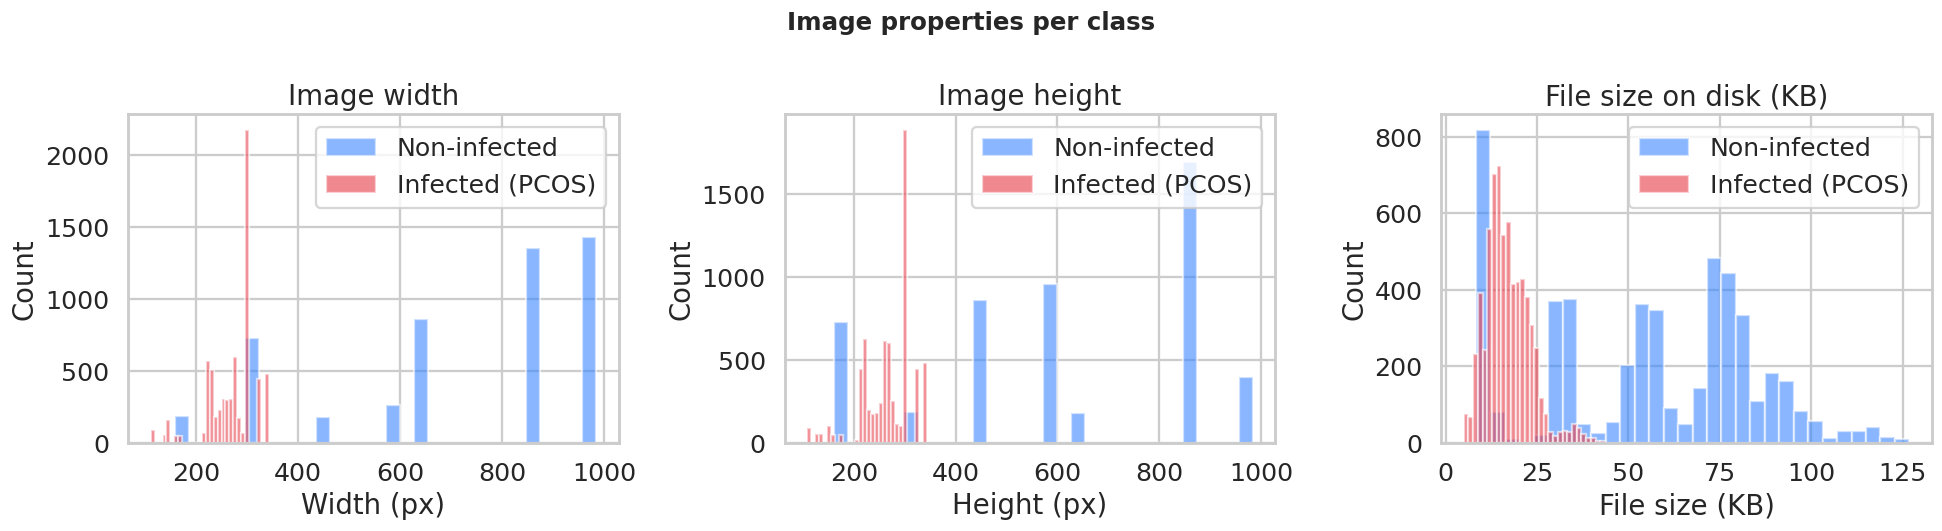

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, xlabel in zip(
    axes, ["width", "height", "filesize_kb"],
    ["Width (px)", "Height (px)", "File size (KB)"],
):
    for label, color in CLASS_COLORS.items():
        sub = df[df["label"] == label]
        ax.hist(sub[col].dropna(), bins=30, alpha=0.6,
                color=color, label=CLASS_NAMES[label], edgecolor="white")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend()

axes[0].set_title("Image width")
axes[1].set_title("Image height")
axes[2].set_title("File size on disk (KB)")

fig.suptitle("Image properties per class", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_image_properties.png")
plt.show()

In [6]:
print("Per-class summary")
summary = df.groupby("class_name").agg(
    n=("path", "count"),
    width_mean=("width", "mean"),
    width_std=("width", "std"),
    height_mean=("height", "mean"),
    height_std=("height", "std"),
    aspect_mean=("aspect_ratio", "mean"),
    mp_mean=("megapixels", "mean"),
    kb_mean=("filesize_kb", "mean"),
).round(2)
summary.to_csv(ART_DIR / "image_properties_summary.csv")
summary

Per-class summary


,n,width_mean,width_std,height_mean,height_std,aspect_mean,mp_mean,kb_mean
class_name,,,,,,,,
infected,6784,272.15,46.47,267.42,48.39,1.02,0.07,17.10
noninfected,5000,718.25,255.35,608.86,261.50,1.30,0.49,54.98


## 3. Pixel-intensity distributions

We sample a representative subset of images (full decode is slow at 11k+ images) and compute per-channel mean, std, and the full histogram. This tells us whether the dataset is dark, bright, or already well-normalised.

Sample tensor shape: (400, 128, 128, 3)  (N, H, W, C)


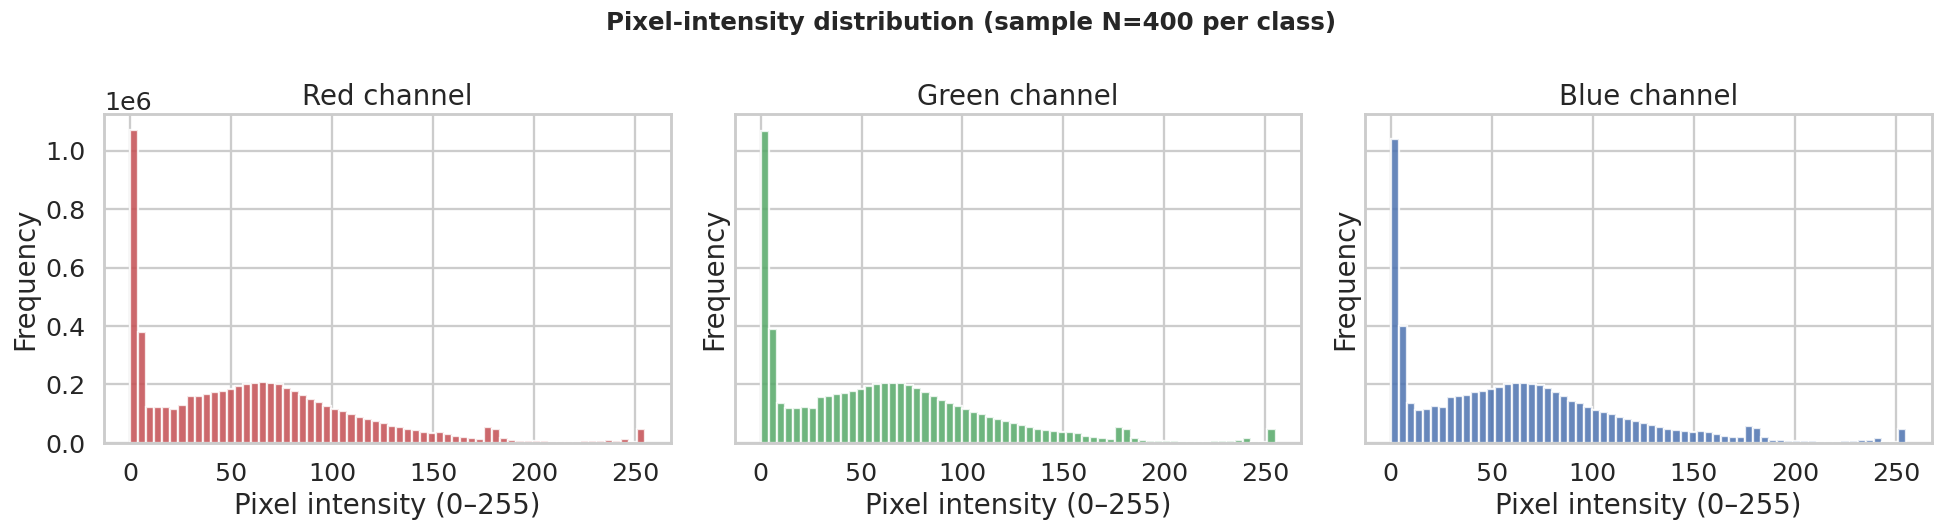

In [7]:
SAMPLE_SIZE = 200  # per class — enough for a stable histogram
rng = np.random.default_rng(42)


def sample_pixels(df: pd.DataFrame, n_per_class: int) -> np.ndarray:
    """Return concatenated pixel values (RGB, 0–255) for the sample."""
    pixels = []
    for label in CLASS_MAP.values():
        sub = df[df["label"] == label]
        chosen = rng.choice(sub["path"].values, size=min(n_per_class, len(sub)), replace=False)
        for p in chosen:
            try:
                im = np.array(Image.open(p).convert("RGB").resize((128, 128)))
                pixels.append(im)
            except Exception:
                continue
    return np.stack(pixels)


sample = sample_pixels(df, SAMPLE_SIZE)
print(f"Sample tensor shape: {sample.shape}  (N, H, W, C)")

channel_names = ["Red", "Green", "Blue"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ch, ax, name in zip(range(3), axes, channel_names):
    ax.hist(sample[..., ch].ravel(), bins=64, color=["r", "g", "b"][ch],
            alpha=0.85, edgecolor="white")
    ax.set_title(f"{name} channel")
    ax.set_xlabel("Pixel intensity (0–255)")
    ax.set_ylabel("Frequency")
fig.suptitle(f"Pixel-intensity distribution (sample N={len(sample)} per class)",
             fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_pixel_histograms.png")
plt.show()

In [8]:
per_class_stats = []
for label in CLASS_MAP.values():
    sub = df[df["label"] == label]
    chosen = rng.choice(sub["path"].values, size=min(100, len(sub)), replace=False)
    means, stds = [], []
    for p in chosen:
        try:
            arr = np.array(Image.open(p).convert("RGB").resize((128, 128)))
            means.append(arr.mean(axis=(0, 1)))
            stds.append(arr.std(axis=(0, 1)))
        except Exception:
            continue
    means = np.array(means)
    stds = np.array(stds)
    per_class_stats.append({
        "class_name": [k for k, v in CLASS_MAP.items() if v == label][0],
        "mean_R": means[:, 0].mean(), "mean_G": means[:, 1].mean(), "mean_B": means[:, 2].mean(),
        "std_R": stds[:, 0].mean(),  "std_G": stds[:, 1].mean(),  "std_B": stds[:, 2].mean(),
    })
stats_df = pd.DataFrame(per_class_stats).round(2)
stats_df.to_csv(ART_DIR / "pixel_statistics.csv", index=False)
stats_df

,class_name,mean_R,mean_G,mean_B,std_R,std_G,std_B
0,noninfected,53.13,53.44,54.41,44.24,44.43,45.02
1,infected,69.50,69.34,70.68,52.62,52.82,53.22


## 4. Sample gallery

A 4×4 grid per class — the first thing the panel will want to see. Random sampling (seeded) so the result is reproducible.

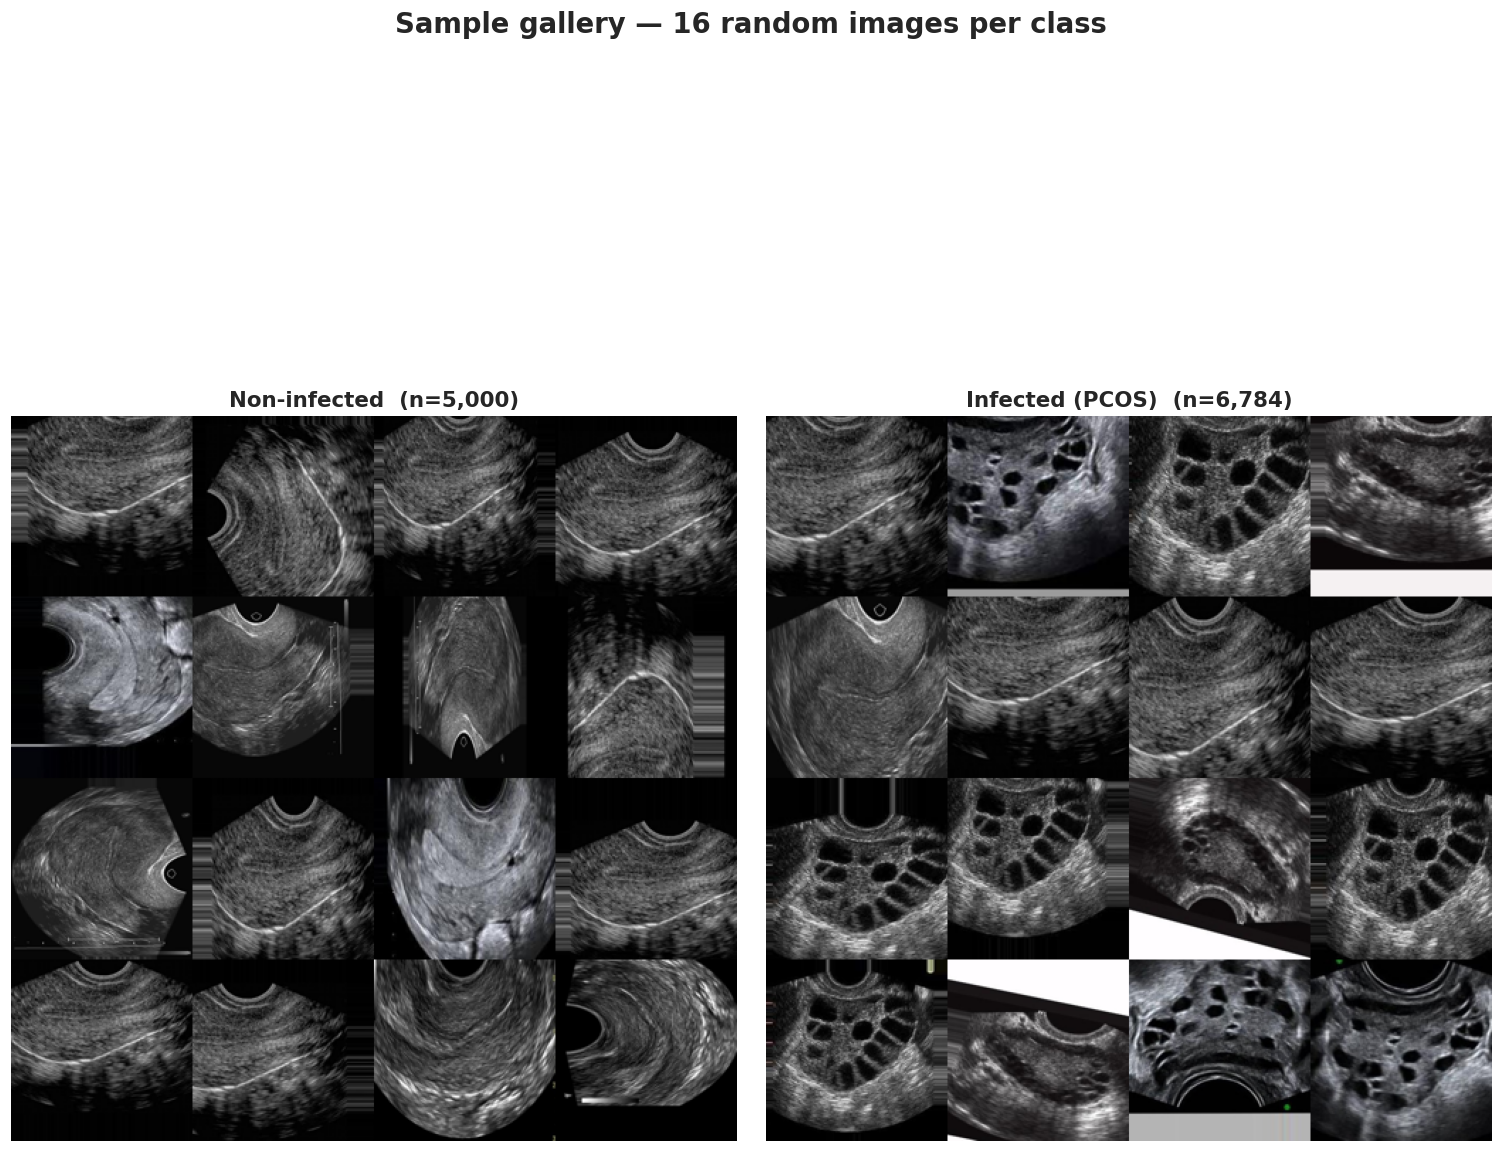

In [9]:
def sample_grid(df: pd.DataFrame, label: int, n: int = 16, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    paths = df[df["label"] == label]["path"].values
    paths = rng.choice(paths, size=n, replace=False)
    tiles = []
    for p in paths:
        im = Image.open(p).convert("RGB").resize((128, 128))
        tiles.append(np.array(im))
    rows = []
    for i in range(0, n, 4):
        rows.append(np.concatenate(tiles[i:i+4], axis=1))
    return np.concatenate(rows, axis=0)


fig, axes = plt.subplots(1, 2, figsize=(14, 14))
for ax, label in zip(axes, [0, 1]):
    grid = sample_grid(df, label, n=16, seed=label)
    ax.imshow(grid)
    ax.set_title(f"{CLASS_NAMES[label]}  (n={len(df[df['label']==label]):,})",
                 fontsize=14, fontweight="bold")
    ax.axis("off")
fig.suptitle("Sample gallery — 16 random images per class",
             fontsize=18, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_sample_gallery.png")
plt.show()

## 5. Quality checks

Three things that silently break training:

1. **Corrupt / truncated files** — caught by `Image.verify()` above.
2. **Near-duplicate images** — exact-byte duplicates. A single bad photo duplicated across the dataset can inflate accuracy and mask overfitting. We flag this aggressively; the panel will ask about it.
3. **Blank / near-uniform images** — images with extremely low variance are useless and can collapse a batch's gradient.

In [10]:
# 5a. Exact duplicates via MD5 hash
def md5_of(path: str) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 16), b""):
            h.update(chunk)
    return h.hexdigest()


df["md5"] = df["path"].apply(md5_of)
dup_groups = df.groupby("md5").filter(lambda g: len(g) > 1)
n_dup_images = len(dup_groups)
n_dup_groups = dup_groups["md5"].nunique()
print(f"Near-duplicate images: {n_dup_images} ({n_dup_groups} unique hashes)")

# Where do the duplicates live? (by class)
dup_by_class = dup_groups["class_name"].value_counts()
print("\nDuplicate distribution by class:")
print(dup_by_class.to_string())

Near-duplicate images: 9744 (1956 unique hashes)

Duplicate distribution by class:
class_name
noninfected    5000
infected       4744


In [11]:
# Show what fraction of each class is unique
unique_per_class = df.drop_duplicates(subset="md5").groupby("class_name").size()
total_per_class = df.groupby("class_name").size()
unique_frac = (unique_per_class / total_per_class).round(3)

print("Unique-image fraction per class:")
for cls in unique_per_class.index:
    print(f"  {cls:14s}: {unique_per_class[cls]:,} unique / {total_per_class[cls]:,} total  ({unique_frac[cls]:.1%})")

Unique-image fraction per class:
  infected      : 3,184 unique / 6,784 total  (46.9%)
  noninfected   : 812 unique / 5,000 total  (16.2%)


Near-uniform images (std < 5.0): 0 / 400


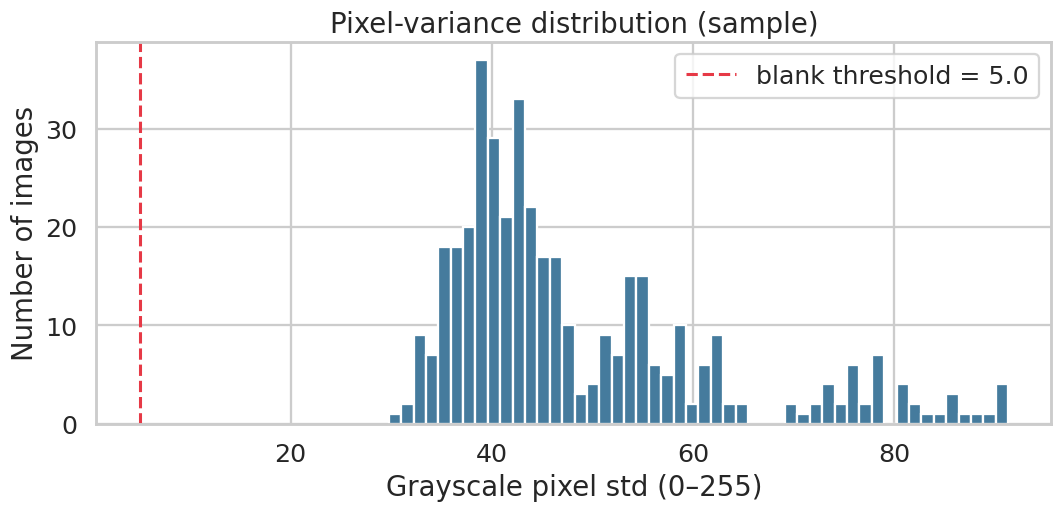

In [12]:
# 5b. Blank / near-uniform images (low pixel std)
sample_for_blank = df.sample(n=min(400, len(df)), random_state=0)
stds = []
for p in sample_for_blank["path"]:
    try:
        arr = np.array(Image.open(p).convert("L").resize((64, 64)))
        stds.append(arr.std())
    except Exception:
        stds.append(np.nan)
sample_for_blank = sample_for_blank.copy()
sample_for_blank["pixel_std"] = stds

BLANK_THRESHOLD = 5.0  # out of 0–255
n_blank = int((sample_for_blank["pixel_std"] < BLANK_THRESHOLD).sum())
print(f"Near-uniform images (std < {BLANK_THRESHOLD}): {n_blank} / {len(sample_for_blank)}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sample_for_blank["pixel_std"].dropna(), bins=50,
        color="#457b9d", edgecolor="white")
ax.axvline(BLANK_THRESHOLD, color="#e63946", linestyle="--", linewidth=2,
           label=f"blank threshold = {BLANK_THRESHOLD}")
ax.set_xlabel("Grayscale pixel std (0–255)")
ax.set_ylabel("Number of images")
ax.set_title("Pixel-variance distribution (sample)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "05_pixel_variance.png")
plt.show()

## 6. Split preview

Apply the same 80/10/10 stratified split the training pipeline uses (`src.data.splitter`) and show the resulting class distributions. This is what we will defend as "no leakage, class balance preserved".

In [13]:
sys.path.insert(0, str(PROJECT_ROOT))
from src.data.splitter import stratified_split

paths = df["path"].tolist()
labels = df["label"].tolist()
groups = df["filename"].tolist()  # filename-as-group proxy (see splitter docs)

train_paths, train_labels, val_paths, val_labels, test_paths, test_labels = \
    stratified_split(paths, labels, patient_ids=groups, seed=42)

print(f"train: {len(train_paths):,}   val: {len(val_paths):,}   test: {len(test_paths):,}")

[Splitter] Using GROUP-AWARE split (10360 groups vs 11784 images) to prevent patient-level leakage.


[Splitter] Split sizes:
  Train: 9410 (class 0: 4000, class 1: 5410)
  Val:   1186 (class 0: 500, class 1: 686)
  Test:  1188 (class 0: 500, class 1: 688)
train: 9,410   val: 1,186   test: 1,188


In [14]:
split_df = pd.DataFrame({
    "split": (["train"] * len(train_labels) +
              ["val"]   * len(val_labels) +
              ["test"]  * len(test_labels)),
    "label": list(train_labels) + list(val_labels) + list(test_labels),
})
split_df["class_name"] = split_df["label"].map({v: k for k, v in CLASS_MAP.items()})

ct = pd.crosstab(split_df["split"], split_df["class_name"])
ct["total"] = ct.sum(axis=1)
ct["infected_frac"] = (ct["infected"] / ct["total"]).round(4)
ct.to_csv(ART_DIR / "split_distribution.csv")
ct

class_name,infected,noninfected,total,infected_frac
split,,,,
test,688,500,1188,0.5791
train,5410,4000,9410,0.5749
val,686,500,1186,0.5784


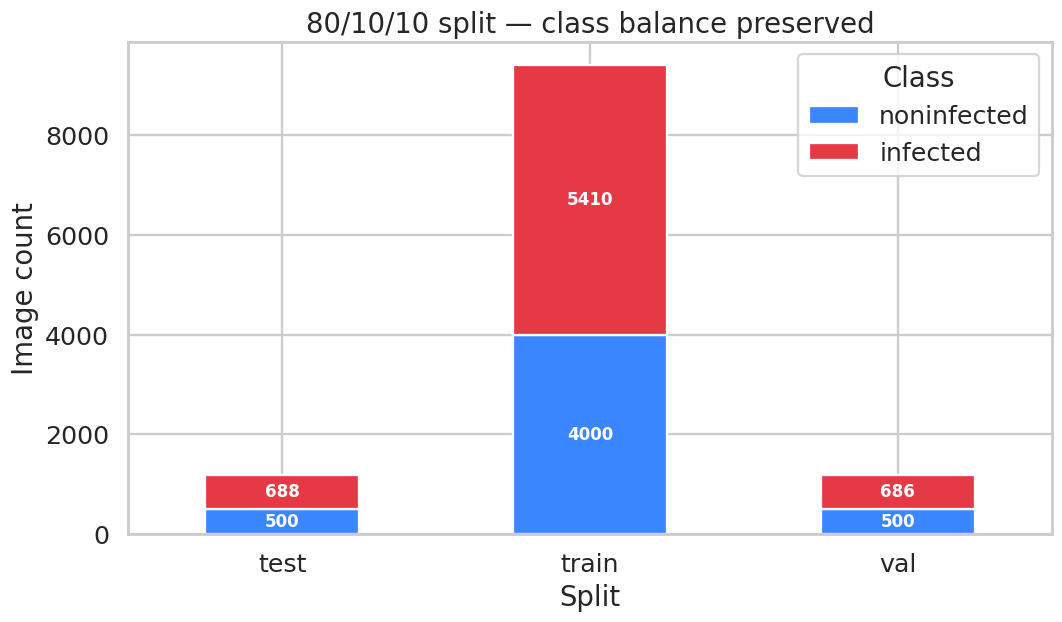

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
ct_no_total = ct.drop(columns=["total", "infected_frac"])
# Order so noninfected is at the bottom (matches CLASS_COLORS key)
ct_ordered = ct_no_total[["noninfected", "infected"]]
ct_ordered.plot(kind="bar", stacked=True, ax=ax,
                color=[CLASS_COLORS[0], CLASS_COLORS[1]],
                edgecolor="white", linewidth=1.5)
ax.set_title("80/10/10 split — class balance preserved")
ax.set_xlabel("Split")
ax.set_ylabel("Image count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Class", loc="upper right")
for container in ax.containers:
    ax.bar_label(container, label_type="center", fontsize=11, color="white", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_split_distribution.png")
plt.show()

## 7. Take-aways for the defense

A tiny summary table the panel can keep on a slide.

In [16]:
takeaways = pd.DataFrame([
    ("Dataset size", f"{len(df):,} images"),
    ("Classes", "infected (PCOS), noninfected"),
    ("Class imbalance ratio", f"{ratios.max() / ratios.min():.2f}x"),
    ("Modal resolution", f"{df['width'].mode()[0]:.0f} x {df['height'].mode()[0]:.0f}"),
    ("Colour mode", df["mode"].mode()[0]),
    ("Corrupt images", int(df['corrupt'].sum())),
    ("Duplicate images", n_dup_images),
    ("Near-uniform images (sample)", n_blank),
    ("Split", "80/10/10 stratified"),
    ("Train / Val / Test",
     f"{len(train_paths):,} / {len(val_paths):,} / {len(test_paths):,}"),
], columns=["Attribute", "Value"])
takeaways.to_csv(ART_DIR / "eda_takeaways.csv", index=False)
takeaways

,Attribute,Value
0,Dataset size,"11,784 images"
1,Classes,"infected (PCOS), noninfected"
2,Class imbalance ratio,1.36x
3,Modal resolution,300 x 300
4,Colour mode,RGB
5,Corrupt images,0
6,Duplicate images,9744
7,Near-uniform images (sample),0
8,Split,80/10/10 stratified
9,Train / Val / Test,"9,410 / 1,186 / 1,188"


## 8. Reproducibility

All figures in this notebook are saved to `notebooks/eda_figures/` and all tables to `notebooks/eda_artifacts/`. The notebook is deterministic via `random_state=42` / `seed=42` — re-running yields identical outputs.